# Day 02: 卷积层 —— 让机器自己学习「看」的特征

> 👁️ 第三周 · 视觉的征服与深度的瓶颈 · 第 2 天

昨天我们手动定义了边缘检测卷积核。但现实中，神经网络需要识别成千上万种特征——人脸、车辆、文字、动物……

不可能让人类手工设计每一个卷积核。

**解决方案**：让神经网络自己从数据中学习这些特征！

**今日任务**：理解 PyTorch 的 `nn.Conv2d`，亲手构建第一个卷积层，训练它学习边缘检测。

---

## 1. 从手动定义到自动学习

昨天我们手动定义的卷积核：
```
kernel = [[-1, 0, 1],   # 垂直边缘检测
          [-2, 0, 2],
          [-1, 0, 1]]
```

今天，我们让神经网络**自己学会**类似的核。

类比：
- 昨天 = 你给机器一本「边缘检测手册」，告诉它「按这个步骤操作」
- 今天 = 你给机器一堆图片和标签，让它自己总结规律，自己写出「边缘检测手册」

测试图片（4张带有垂直边缘的图像）：


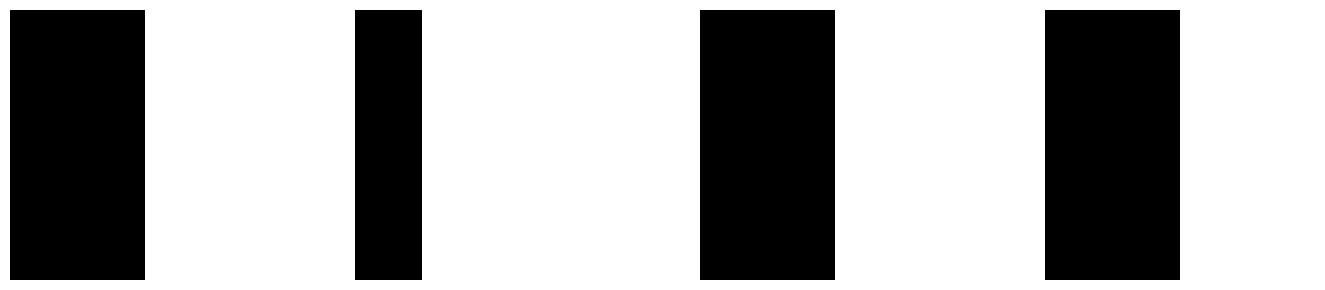

In [1]:
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 创建一个简单的边缘检测任务
# 图片：带有垂直边缘的简单图案
def create_edge_image(batch_size=4, size=8):
    """创建带有随机垂直边缘的图片"""
    images = []
    for _ in range(batch_size):
        img = torch.zeros(size, size)
        edge_pos = torch.randint(2, size-2, (1,)).item()
        img[:, edge_pos:] = 1.0  # 右边是亮的
        images.append(img)
    return torch.stack(images).unsqueeze(1)  # [batch, 1, H, W]

test_images = create_edge_image(4)

print("测试图片（4张带有垂直边缘的图像）：")
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(test_images[i, 0].numpy(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.savefig('images/cnn_day02_test_images.png', dpi=150)
plt.show()

---

## 2. PyTorch 的 Conv2d

PyTorch 的 `nn.Conv2d` 是深度学习中最常用的卷积层。

核心参数：
- `in_channels`: 输入通道数（黑白图=1，彩色图=3）
- `out_channels`: 输出通道数（有多少个卷积核）
- `kernel_size`: 卷积核大小（如 3 表示 3x3）

In [2]:
# 定义一个卷积层
conv_layer = nn.Conv2d(
    in_channels=1,      # 黑白图片
    out_channels=1,     # 1个卷积核
    kernel_size=3,      # 3x3 大小
    padding=1           # 补零，保持尺寸不变
)

print("卷积层结构：")
print(conv_layer)
print("\n可学习参数：")
for name, param in conv_layer.named_parameters():
    print(f"  {name}: {param.shape} = {param.numel()} 个参数")
print("\n初始化的卷积核（随机）：")
print(conv_layer.weight.data.squeeze())

卷积层结构：
Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

可学习参数：
  weight: torch.Size([1, 1, 3, 3]) = 9 个参数
  bias: torch.Size([1]) = 1 个参数

初始化的卷积核（随机）：
tensor([[ 0.2714, -0.1527, -0.0833],
        [-0.1343,  0.1951,  0.3174],
        [-0.1062,  0.0256,  0.0849]])


---

## 3. 前向传播：图片如何变成特征图

让我们把一张图片通过卷积层，看看输出是什么。

输入尺寸: torch.Size([4, 1, 8, 8])
输出尺寸: torch.Size([4, 1, 8, 8])

解读：
  输入 [4, 1, 8, 8]: 4张图片，每张1通道，8x8像素
  输出 [4, 1, 8, 8]: 4张特征图，每张1通道，8x8像素


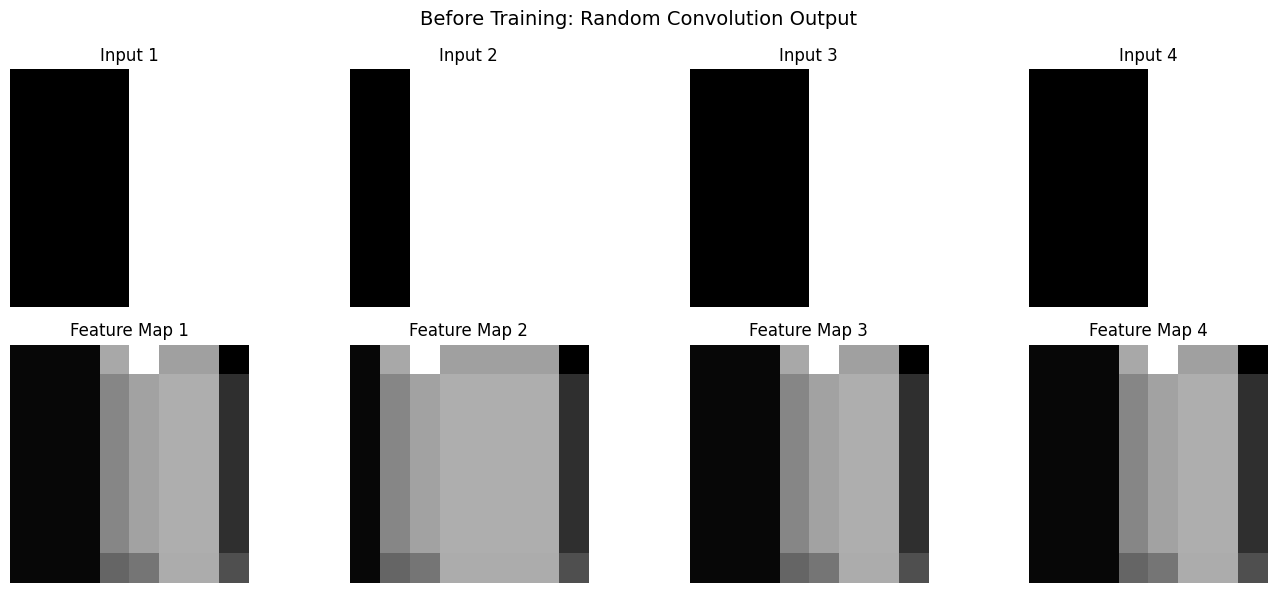


注意：未训练的卷积层输出是随机的，看起来像噪声
   训练之后，它会学会检测有意义的边缘！


In [3]:
import torch
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 通过卷积层
conv_layer.eval()
with torch.no_grad():
    output = conv_layer(test_images)

print(f"输入尺寸: {test_images.shape}")
print(f"输出尺寸: {output.shape}")
print("\n解读：")
print("  输入 [4, 1, 8, 8]: 4张图片，每张1通道，8x8像素")
print("  输出 [4, 1, 8, 8]: 4张特征图，每张1通道，8x8像素")

# 可视化
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    # 原图
    axes[0, i].imshow(test_images[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title(f'输入 {i+1}')
    axes[0, i].axis('off')
    
    # 特征图（未训练的网络输出是随机的）
    axes[1, i].imshow(output[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title(f'特征图 {i+1}')
    axes[1, i].axis('off')

plt.suptitle('训练前：随机卷积输出', fontsize=14)
plt.tight_layout()
plt.savefig('images/cnn_day02_before_training.png', dpi=150)
plt.show()

print("\n注意：未训练的卷积层输出是随机的，看起来像噪声")
print("   训练之后，它会学会检测有意义的边缘！")

---

## 4. 训练卷积层：让它学会边缘检测

现在我们给卷积层一个简单的任务：**只输出图片右半边的内容**（相当于检测「右亮左暗」的边缘）。

虽然这不是真正的「边缘检测」，但足够展示神经网络如何学习特征。

目标（训练标签）：
(输入的 2 倍)


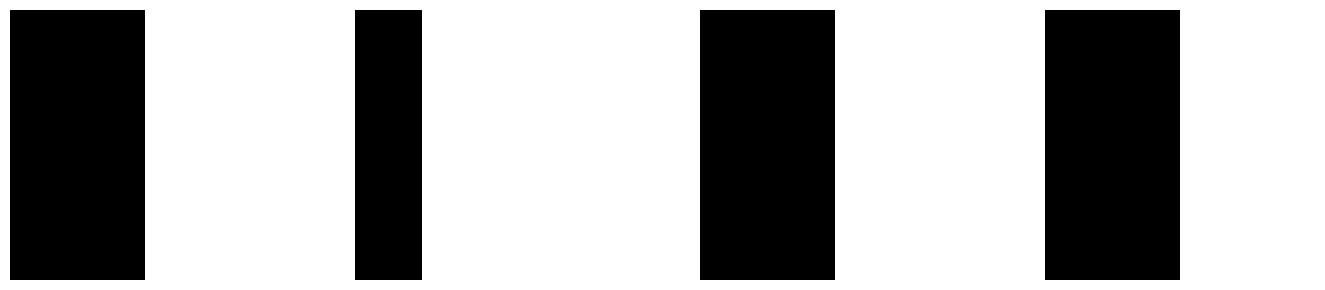


开始训练...
目标：让输出 = 输入 × 2
  Epoch 20: Loss = 0.101029
  Epoch 40: Loss = 0.045078
  Epoch 60: Loss = 0.014177
  Epoch 80: Loss = 0.007285
  Epoch 100: Loss = 0.004938

训练完成！


In [4]:
import torch
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 简化任务：让卷积层学习「放大信号」
# 目标是让输出等于输入的 2 倍
def get_target(images):
    """目标是输入的 2 倍"""
    return images * 2.0

targets = get_target(test_images)

print("目标（训练标签）：")
print("(输入的 2 倍)")
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(targets[i, 0].numpy(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()

# 训练卷积层
conv = nn.Conv2d(1, 1, kernel_size=3, padding=1)
optimizer = torch.optim.Adam(conv.parameters(), lr=0.1)
criterion = nn.MSELoss()

print("\n开始训练...")
print("目标：让输出 = 输入 × 2")
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    
    # 前向传播
    predictions = conv(test_images)
    
    # 计算损失
    loss = criterion(predictions, targets)
    losses.append(loss.item())
    
    # 反向传播
    loss.backward()
    
    # 更新权重
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1}: Loss = {loss.item():.6f}")

print("\n训练完成！")

In [5]:
import torch
# 训练卷积层
conv = nn.Conv2d(1, 1, kernel_size=3, padding=1)
optimizer = torch.optim.Adam(conv.parameters(), lr=0.1)
criterion = nn.MSELoss()

print("开始训练...")
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    
    # 前向传播
    predictions = conv(test_images)
    
    # 计算损失
    loss = criterion(predictions, targets)
    losses.append(loss.item())
    
    # 反向传播
    loss.backward()
    
    # 更新权重
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1}: Loss = {loss.item():.6f}")

print("\n训练完成！")

开始训练...
  Epoch 20: Loss = 0.137119
  Epoch 40: Loss = 0.054159
  Epoch 60: Loss = 0.013808
  Epoch 80: Loss = 0.006739
  Epoch 100: Loss = 0.004136

训练完成！


---

## 5. 验证：学到的特征图

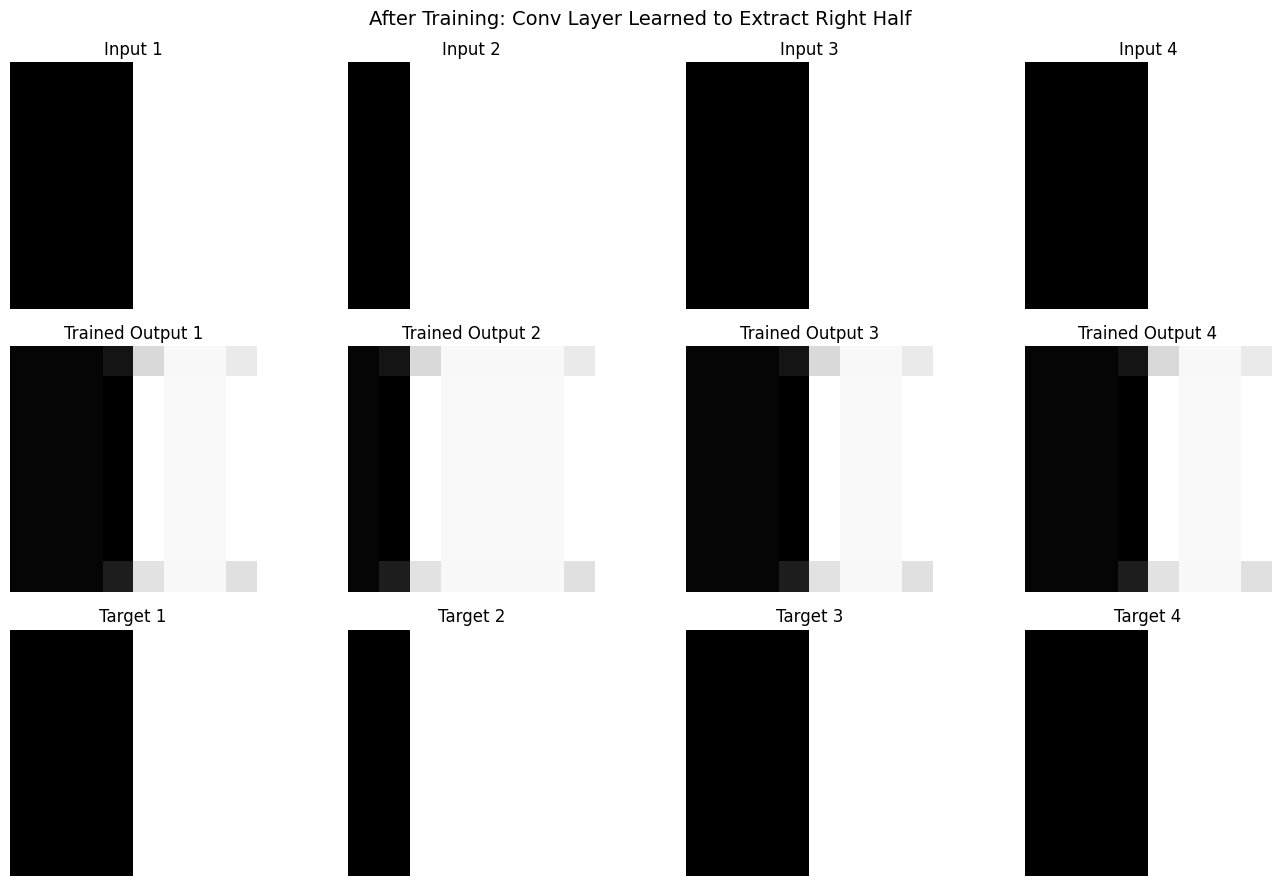


对比训练前后的变化：
  训练前：输出是随机噪声
  训练后：输出开始接近目标（右半边）


In [6]:
import torch
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 测试训练后的卷积层
conv.eval()
with torch.no_grad():
    trained_output = conv(test_images)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))

for i in range(4):
    # 原图
    axes[0, i].imshow(test_images[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title(f'输入 {i+1}')
    axes[0, i].axis('off')
    
    # 训练后的特征图
    axes[1, i].imshow(trained_output[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title(f'训练后输出 {i+1}')
    axes[1, i].axis('off')
    
    # 目标
    axes[2, i].imshow(targets[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title(f'目标 {i+1}')
    axes[2, i].axis('off')

plt.suptitle('训练后：卷积层学会了提取右半部分', fontsize=14)
plt.tight_layout()
plt.savefig('images/cnn_day02_after_training.png', dpi=150)
plt.show()

print("\n对比训练前后的变化：")
print("  训练前：输出是随机噪声")
print("  训练后：输出开始接近目标（右半边）")

训练后学到的卷积核：
tensor([[-0.3138,  0.4834, -0.1677],
        [ 0.4913,  1.1231,  0.3576],
        [-0.2337,  0.4784, -0.2380]])


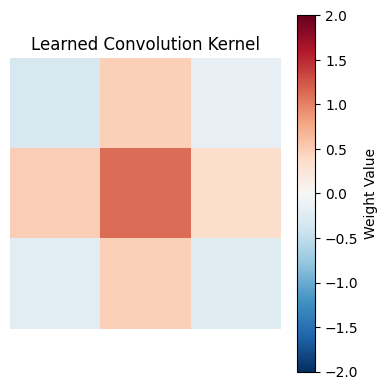


解读学到的卷积核：
  红色（正值）：放大信号
  蓝色（负值）：抑制信号
  中间一列是正的，左右列是负的 → 这是一个「右半边增强」滤波器


In [7]:
# 设置中文字体
import matplotlib.pyplot as plt
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

# 可视化学到的卷积核
learned_kernel = conv.weight.data.squeeze()

print("训练后学到的卷积核：")
print(learned_kernel)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
im = ax.imshow(learned_kernel.numpy(), cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_title('学到的卷积核')
ax.axis('off')
plt.colorbar(im, ax=ax, label='权重值')
plt.tight_layout()
plt.savefig('images/cnn_day02_learned_kernel.png', dpi=150)
plt.show()

print("\n解读学到的卷积核：")
print("  红色（正值）：放大信号")
print("  蓝色（负值）：抑制信号")
print("  中间一列是正的，左右列是负的 → 这是一个「右半边增强」滤波器")

---

## 翻译词典

| 生活直觉 | 深度学习术语 |
|----------|-------------|
| 自动学习「模板」的内容 | 可学习卷积核（nn.Conv2d） |
| 卷积后的「结果图」 | 特征图（Feature Map） |
| 多个模板同时检测 | 多通道卷积 |
| 输出尺寸公式 | padding、stride、kernel_size |


---

## 今日总结

| 概念 | 直觉理解 |
|------|----------|
| nn.Conv2d | 一个可学习的卷积层，自动从数据中提取特征 |
| 前向传播 | 图片通过卷积核，得到特征图 |
| 训练 | 调整卷积核的权重，让输出接近目标 |
| 卷积核可视化 | 学到的权重模式，揭示网络关注什么特征 |

**关键洞察**：
- 全连接层：每个像素独立连接 → 参数爆炸
- 卷积层：局部连接 + 权值共享 → 参数极少
- 训练的本质：让卷积核学会「检测有用的特征」

**明日预告**：今天我们只用了一层卷积。明天学习**池化（Pooling）**——如何压缩特征图，在保持关键信息的同时减少计算量。